# Insights — três perguntas que os dados respondem

O `03_modeling` estabeleceu *o que* move o rating (qualidade do jogador + impacto na partida) e
*quanto* dá para explicar (~29% — o resto é ruído do gerador sintético). Este notebook fecha o
projeto respondendo três perguntas concretas, cada uma no formato **pergunta → gráfico → conclusão**:

1. **Quem foi o melhor jogador da Copa?** — a pergunta que dá nome ao projeto.
2. **Se o rating de uma partida é tão ruidoso, como a "qualidade" aparece?** — o insight
   estatístico central do projeto.
3. **Quanto vale um gol? E uma vitória?** — o preço, em pontos de rating, dos eventos da partida.

Todas as figuras são salvas em `figures/`.

## 1. Ferramentas, estilo e dados

Mesmo setup visual do `03_modeling` (uma cor por série, texto em tons de tinta, grade recessiva)
e as mesmas decisões de escopo: só linhas com `minutes_played > 0`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

AZUL = "#2a78d6"
TINTA = "#0b0b0b"
TINTA_2 = "#52514e"
TINTA_MUTED = "#898781"
GRADE = "#e1e0d9"
EIXO = "#c3c2b7"

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": EIXO, "axes.linewidth": 1.0,
    "axes.titlecolor": TINTA, "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlepad": 12,
    "axes.labelcolor": TINTA_2, "axes.labelsize": 11,
    "xtick.color": TINTA_MUTED, "ytick.color": TINTA_MUTED,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "axes.grid": True, "grid.color": GRADE, "grid.linewidth": 1.0, "grid.linestyle": "-",
    "axes.axisbelow": True,
    "font.family": "sans-serif",
})

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

def salvar(fig, nome):
    caminho = FIG_DIR / nome
    fig.savefig(caminho, dpi=150, bbox_inches="tight")
    print(f"Figura salva em {caminho}")

data_df = pd.read_csv("../data/fifa_world_cup_2026_player_performance.csv")
played_df = data_df[data_df["minutes_played"] > 0].copy()
print(f"{len(played_df)} atuações de {played_df['player_name'].nunique()} jogadores")

31558 atuações de 1245 jogadores


## 2. Pergunta 1 — quem foi o melhor jogador da Copa?

A resposta ingênua seria "o maior rating médio". A armadilha: com poucos jogos, uma média é
instável — um jogador com 3 partidas boas lideraria o ranking por sorte, não por mérito. Por isso
exigimos um **mínimo de 20 partidas** (a mediana do dataset é ~25 por jogador), o mesmo espírito
dos critérios de "mínimo de jogos" em rankings esportivos reais.

Para o gráfico, um detalhe de boas práticas: rankings com valores próximos (todos entre ~7.4 e
7.6) **não devem virar barras** — barra precisa começar em zero (senão a diferença visual mente),
e começando em zero as diferenças somem. Um **dot plot** resolve: pontos podem viver em um eixo
recortado sem distorcer nada.

Figura salva em figures/04_melhor_jogador.png


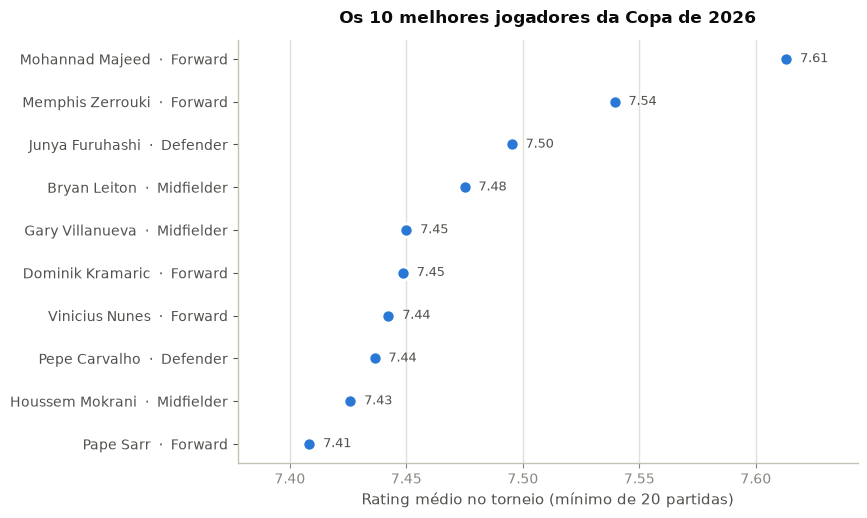

In [2]:
player_stats = played_df.groupby("player_name").agg(
    rating_medio=("player_rating", "mean"),
    jogos=("player_rating", "size"),
    posicao=("position", "first"),
    valor=("market_value_eur", "first"),
)

elegiveis = player_stats[player_stats["jogos"] >= 20]
top10 = elegiveis.sort_values("rating_medio").tail(10)

fig, ax = plt.subplots(figsize=(8, 5.5))

posicoes = np.arange(len(top10))
ax.scatter(top10["rating_medio"], posicoes, s=90, color=AZUL,
           edgecolor="white", linewidth=2, zorder=3)
for i, (nome, linha) in enumerate(top10.iterrows()):
    ax.annotate(f"{linha['rating_medio']:.2f}", xy=(linha["rating_medio"], i),
                xytext=(10, 0), textcoords="offset points",
                va="center", color=TINTA_2, fontsize=9)

ax.set_yticks(posicoes)
ax.set_yticklabels([f"{nome}  ·  {p}" for nome, p in zip(top10.index, top10["posicao"])])
ax.tick_params(axis="y", colors=TINTA_2)
ax.grid(axis="y", visible=False)
ax.margins(x=0.15)
ax.set_xlabel("Rating médio no torneio (mínimo de 20 partidas)")
ax.set_title("Os 10 melhores jogadores da Copa de 2026")

salvar(fig, "04_melhor_jogador.png")
plt.show()

**Resposta: Mohannad Majeed**, atacante, rating médio de 7.61 em 23 partidas.

Dois detalhes que enriquecem a resposta:

- **O melhor jogador não é o mais caro.** Majeed vale ~72M de euros; Dominik Kramaric, com quase
  o mesmo rating, vale ~191M. O ranking por desempenho e o ranking por valor de mercado não são o
  mesmo ranking — coerente com os retornos decrescentes do valor de mercado que a curva de
  dependência parcial mostrou no `03_modeling`.
- **O topo não é só de atacantes.** Entre os 10 há defensores e meias — o rating do dataset premia
  posições diferentes de forma razoavelmente equilibrada (as médias por posição variam pouco:
  6.21 a 6.36).

## 3. Pergunta 2 — onde a "qualidade" aparece, se a partida é tão ruidosa?

O `03_modeling` mostrou que `consistency_score` é a feature mais importante — mas mesmo assim o
modelo só explica ~29% do rating de *uma partida*. Como conciliar "é o atributo mais importante"
com "explica pouco"?

A resposta é estatística, e é o insight central do projeto: **o rating de uma partida individual é
dominado por ruído, mas o ruído se cancela na média**. Cada jogador tem ~25 partidas; ao agregar,
a "sorte" de cada jogo (positiva e negativa) se anula e sobra o sinal do jogador — a lei dos
grandes números em ação.

O gráfico certo para isso é um **par de painéis com os mesmos eixos**: à esquerda, cada ponto é
uma atuação; à direita, cada ponto é um jogador (média de ≥20 partidas). Mesma feature, mesma
escala — só muda o nível de agregação.

Figura salva em figures/04_sinal_na_media.png


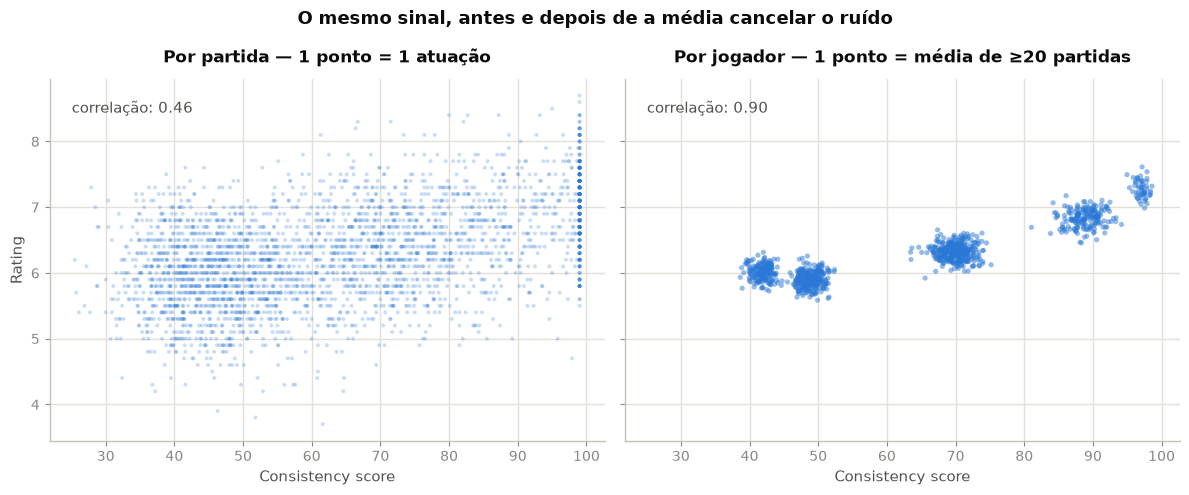

In [3]:
por_jogador = elegiveis.join(
    played_df.groupby("player_name")["consistency_score"].mean().rename("consistency")
)

amostra = played_df.sample(3000, random_state=42)

r_partida = played_df["consistency_score"].corr(played_df["player_rating"])
r_jogador = por_jogador["consistency"].corr(por_jogador["rating_medio"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

axes[0].scatter(amostra["consistency_score"], amostra["player_rating"],
                s=8, alpha=0.25, color=AZUL, edgecolor="none")
axes[0].set_title("Por partida — 1 ponto = 1 atuação")
axes[0].set_ylabel("Rating")

axes[1].scatter(por_jogador["consistency"], por_jogador["rating_medio"],
                s=14, alpha=0.5, color=AZUL, edgecolor="none")
axes[1].set_title("Por jogador — 1 ponto = média de ≥20 partidas")

for ax, r in zip(axes, [r_partida, r_jogador]):
    ax.annotate(f"correlação: {r:.2f}", xy=(0.04, 0.94), xycoords="axes fraction",
                va="top", color=TINTA_2, fontsize=11)
    ax.set_xlabel("Consistency score")

fig.suptitle("O mesmo sinal, antes e depois de a média cancelar o ruído",
             color=TINTA, fontsize=13, fontweight="bold")
fig.tight_layout()

salvar(fig, "04_sinal_na_media.png")
plt.show()

A correlação salta de **0.46 por partida para 0.90 por jogador** — o painel direito é
visivelmente mais "apertado" na vertical, com a nuvem colapsando em grupos bem definidos.

E há um bônus que só a visualização entrega: no painel por jogador, os pontos **não formam uma
nuvem contínua — formam camadas discretas** de consistência (~40–50, ~65–75, ~85–100). O gerador
sintético aparentemente sorteou os jogadores em *tiers* de qualidade, e a média por jogador expõe
essa estrutura escondida (por partida, com o ruído por cima, ela é invisível).

Duas consequências práticas:

- **O R² de 0.29 do modelo não era fraqueza do algoritmo** — era o teto da pergunta. Prever *uma
  partida* é prever ruído; prever *o nível de um jogador* é quase determinístico neste dataset
  (r = 0.90 numa feature só).
- **A pergunta define a dificuldade.** Se o objetivo de negócio fosse "avaliar jogadores" (e não
  "prever partidas"), a formulação certa seria agregar primeiro e modelar depois — e as métricas
  seriam radicalmente melhores. Escolher a granularidade do problema é uma decisão de modelagem
  tão importante quanto escolher o algoritmo.

## 4. Pergunta 3 — quanto vale um gol? E uma vitória?

As duas features de *partida* mais importantes do modelo foram `goals` e `match_result`. Vamos
medir o efeito delas diretamente, em pontos de rating.

Boas práticas aqui: como comparamos médias de grupos com tamanhos muito diferentes (28.815
atuações sem gol vs. apenas 17 com 3+), mostramos o **intervalo de confiança de 95%** de cada
média — sem ele, o ponto do grupo raro pareceria tão confiável quanto o do grupo gigante.

Figura salva em figures/04_gol_e_resultado.png


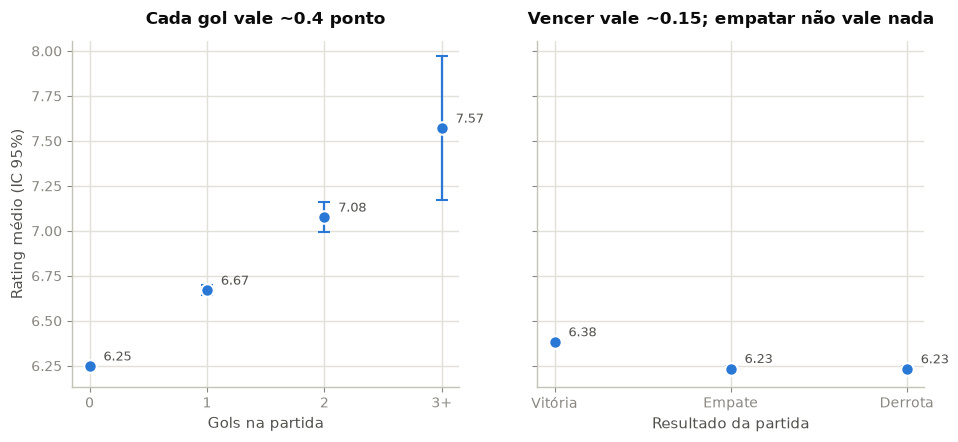

In [4]:
com_gols = played_df.assign(gols=played_df["goals"].clip(upper=3))
por_gols = com_gols.groupby("gols")["player_rating"].agg(["mean", "std", "size"])
por_gols["ic95"] = 1.96 * por_gols["std"] / np.sqrt(por_gols["size"])

ordem_resultado = ["W", "D", "L"]
por_resultado = played_df.groupby("match_result")["player_rating"].agg(["mean", "std", "size"]).loc[ordem_resultado]
por_resultado["ic95"] = 1.96 * por_resultado["std"] / np.sqrt(por_resultado["size"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)

axes[0].errorbar(por_gols.index, por_gols["mean"], yerr=por_gols["ic95"],
                 fmt="o", color=AZUL, markersize=9, capsize=4, linewidth=1.6,
                 markeredgecolor="white", markeredgewidth=1.5)
for x, linha in por_gols.iterrows():
    axes[0].annotate(f"{linha['mean']:.2f}", xy=(x, linha["mean"]),
                     xytext=(10, 4), textcoords="offset points", color=TINTA_2, fontsize=9)
axes[0].set_xticks(por_gols.index)
axes[0].set_xticklabels(["0", "1", "2", "3+"])
axes[0].set_xlabel("Gols na partida")
axes[0].set_ylabel("Rating médio (IC 95%)")
axes[0].set_title("Cada gol vale ~0.4 ponto")

axes[1].errorbar(range(3), por_resultado["mean"], yerr=por_resultado["ic95"],
                 fmt="o", color=AZUL, markersize=9, capsize=4, linewidth=1.6,
                 markeredgecolor="white", markeredgewidth=1.5)
for x, (_, linha) in enumerate(por_resultado.iterrows()):
    axes[1].annotate(f"{linha['mean']:.2f}", xy=(x, linha["mean"]),
                     xytext=(10, 4), textcoords="offset points", color=TINTA_2, fontsize=9)
axes[1].set_xticks(range(3))
axes[1].set_xticklabels(["Vitória", "Empate", "Derrota"])
axes[1].set_xlabel("Resultado da partida")
axes[1].set_title("Vencer vale ~0.15; empatar não vale nada")

salvar(fig, "04_gol_e_resultado.png")
plt.show()

Os dois painéis dividem a **mesma escala de propósito**: o achatamento do painel direito não é
defeito, é a mensagem — o efeito do resultado é quase invisível perto da escada dos gols.

Lendo os números:

- **Um gol vale ~+0.4 de rating, e o efeito é quase linear**: 6.25 → 6.67 → 7.08 → 7.57. O
  intervalo largo no degrau "3+" é honestidade estatística: são só 17 atuações, a média é incerta.
- **Vencer adiciona ~+0.15... mas empatar não vale nada**: empate (6.23) e derrota (6.23) têm
  exatamente a mesma média. Para a "nota" deste dataset, o único resultado que importa é a vitória
  — um empate heroico não é recompensado.
- Colocando em perspectiva: **um gol vale quase três vitórias** em pontos de rating. O gerador da
  nota premia o brilho individual muito mais que o resultado coletivo.

## 5. Conclusões do projeto

As três respostas, em uma linha cada:

| Pergunta | Resposta |
|---|---|
| Quem foi o melhor jogador? | Mohannad Majeed (7.61 em 23 jogos) — e o melhor ≠ o mais caro |
| Onde a qualidade aparece? | Na média: r = 0.46 por partida → **0.90** por jogador; o ruído se cancela |
| Quanto valem gol e vitória? | ~+0.4 por gol (linear), ~+0.15 por vitória; empate = derrota |

E o arco completo do projeto, do `01_eda` até aqui: identificamos e removemos o vazamento que
teria dado um R² de 0.99 falso; construímos features com justificativa para cada exclusão;
treinamos um gradient boosting honesto (R² 0.29 por partida); e fechamos mostrando que o que
parecia "pouco explicável" no nível da partida é quase determinístico no nível do jogador — a
pergunta certa importa mais que o modelo.